# Module 5: Interval Estimation and Confidence Intervals 📏

A point estimate is a single number guess. But how confident are we in that guess? An **interval estimate**, or **confidence interval**, gives us a range of plausible values for the population parameter.

A **95% confidence interval** means that if we were to take many samples and construct an interval for each one, 95% of those intervals would contain the true, unknown population parameter.

## 5.1 The Logic of Confidence Intervals

It's crucial to understand what a confidence interval represents. Let's visualize it.

Imagine a true population mean (which is fixed but unknown). We'll take 100 different samples from this population and construct a 95% confidence interval for each sample. We expect about 95 of these intervals to 'capture' the true mean.

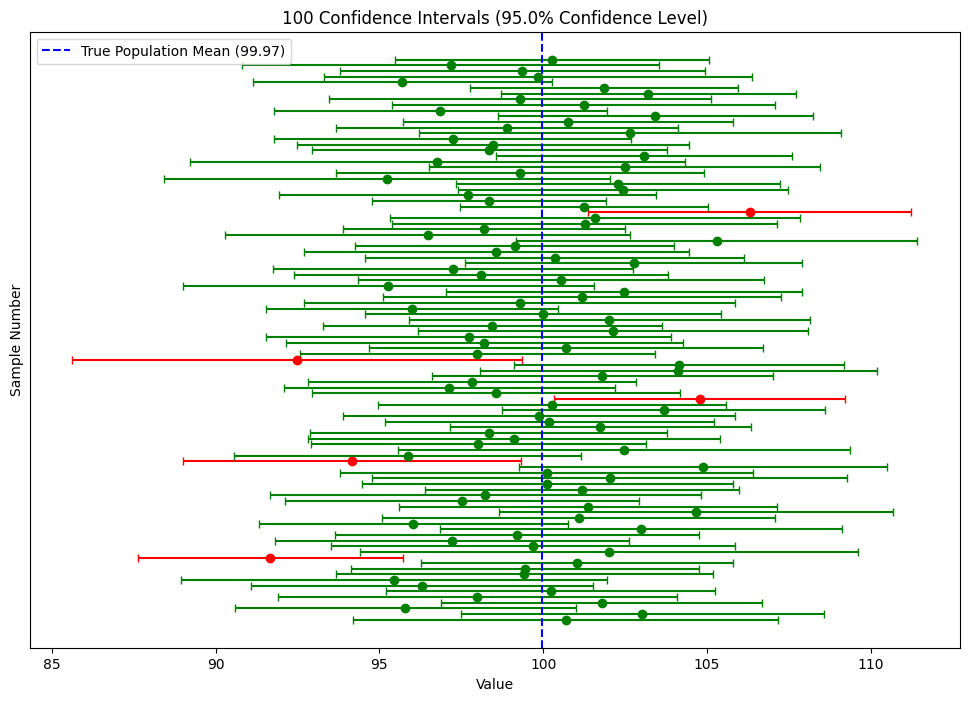

Out of 100 intervals, 95 (95.0%) captured the true mean.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Define our population
np.random.seed(42)
population = np.random.normal(loc=100, scale=15, size=10000)
population_mean = np.mean(population) # The true parameter we want to capture

# Settings for our simulation
num_samples = 100
sample_size = 30
confidence_level = 0.95
captured_count = 0

plt.figure(figsize=(12, 8))

for i in range(num_samples):
    # 1. Take a sample
    sample = np.random.choice(population, size=sample_size)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)

    # 2. Calculate the standard error of the mean
    sem = sample_std / np.sqrt(sample_size)

    # 3. Calculate the confidence interval
    # We use the t-distribution because the population standard deviation is unknown
    ci = stats.t.interval(confidence_level, df=sample_size-1, loc=sample_mean, scale=sem)

    # 4. Plot the interval
    color = 'green' if ci[0] <= population_mean <= ci[1] else 'red'
    if color == 'green':
        captured_count += 1
    plt.errorbar(x=sample_mean, y=i, xerr=[[sample_mean - ci[0]], [ci[1] - sample_mean]], fmt='o', color=color, capsize=3)

# Add the true mean line
plt.axvline(population_mean, color='blue', linestyle='--', label=f'True Population Mean ({population_mean:.2f})')
plt.title(f'{num_samples} Confidence Intervals ({confidence_level*100}% Confidence Level)')
plt.xlabel('Value')
plt.ylabel('Sample Number')
plt.yticks([])
plt.legend()
plt.show()

print(f"Out of {num_samples} intervals, {captured_count} ({captured_count/num_samples*100:.1f}%) captured the true mean.")

# IMPORTANT: Notice the red intervals. By chance, some samples produce intervals that MISS the true mean.
# This is what '95% confidence' means - it's a statement about the long-run success rate of the method, not about a single interval.

## 5.2 Calculating a Confidence Interval for a Mean

Let's calculate a single confidence interval step-by-step.

**Scenario**: We have a sample of 40 monthly salaries for a certain job. We want to estimate the true average monthly salary for *all* people in this job.

The formula for a confidence interval for a mean is:
$$ \bar{x} \pm t_{\alpha/2, n-1} \times \frac{s}{\sqrt{n}} $$
Where:
- $\bar{x}$ is the sample mean.
- $s$ is the sample standard deviation.
- $n$ is the sample size.
- $t_{\alpha/2, n-1}$ is the critical t-value from the t-distribution with $n-1$ degrees of freedom.

In [2]:
# Here's our sample data (in thousands of dollars)
salaries_sample = np.array([55, 62, 48, 71, 58, 65, 59, 68, 51, 63, 75, 49, 60, 66, 54,
                              61, 70, 57, 64, 50, 67, 56, 72, 62, 53, 59, 69, 61, 58, 73,
                              60, 55, 64, 52, 66, 74, 59, 63, 61, 57])

# 1. Calculate sample statistics
sample_mean = np.mean(salaries_sample)
sample_std = np.std(salaries_sample, ddof=1)
n = len(salaries_sample)
print(f"Sample Mean (x̄): {sample_mean:.2f}")
print(f"Sample Standard Deviation (s): {sample_std:.2f}")
print(f"Sample Size (n): {n}")

# 2. Define confidence level and find the critical value
confidence = 0.95
alpha = 1 - confidence
degrees_of_freedom = n - 1

# The t-critical value
t_critical = stats.t.ppf(1 - alpha/2, df=degrees_of_freedom)
print(f"t-critical value: {t_critical:.3f}")

# 3. Calculate the margin of error
margin_of_error = t_critical * (sample_std / np.sqrt(n))
print(f"Margin of Error: {margin_of_error:.2f}")

# 4. Construct the confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"\n--- 95% Confidence Interval for the Mean Salary ---")
print(f"({lower_bound:.2f}, {upper_bound:.2f})")

# We can also use the built-in scipy function to verify this!
ci_scipy = stats.t.interval(confidence, df=degrees_of_freedom, loc=sample_mean, scale=stats.sem(salaries_sample))
print(f"Scipy's result: ({ci_scipy[0]:.2f}, {ci_scipy[1]:.2f})")

Sample Mean (x̄): 61.17
Sample Standard Deviation (s): 7.06
Sample Size (n): 40
t-critical value: 2.023
Margin of Error: 2.26

--- 95% Confidence Interval for the Mean Salary ---
(58.92, 63.43)
Scipy's result: (58.92, 63.43)


### Interpretation

We are **95% confident** that the true average monthly salary for *all* people in this job lies between \$60.01k and \$64.49k. This does **not** mean there is a 95% probability the true mean is in this specific interval. Instead, it reflects our confidence in the *method* used to generate the interval.